Setting

In [129]:
SEARCH_BEST_ESTIMATOR_XGBOOST = True
VERBOSE = True

#XGBOOST PARAMETER
objective='rank:pairwise'
learning_rate=0.1
max_depth=6
n_estimators=200       # Aumentiamo questo valore per dare spazio all'early stopping
colsample_bytree=0.7
subsample=0.7
tree_method='hist'    # Più veloce
eval_metric='ndcg@20'   # Metrica per la validazione
random_state=42
early_stopping_rounds=150

In [130]:
import sys
sys.path.insert(0, "../My_RecSys_Course_AT_PoliMi")
import numpy as np
np.random.seed(1234)

import pandas as pd
import scipy.sparse as sps
path = "Data/data_train.csv"  # cartella da esplorare
# carica
df = pd.read_csv(path, low_memory=False)
userID_unique = df["row"].unique()
itemID_unique = df["col"].unique()
n_users = len(userID_unique)
n_items = len(itemID_unique)
data = np.ones(len(df))


URM_all = sps.csr_matrix((data, 
                          (df["row"].values, df["col"].values)),
                        shape = (n_users, n_items))


from Data_manager.split_functions.split_train_validation_random_holdout import split_train_in_two_percentage_global_sample
from Evaluation.Evaluator import EvaluatorHoldout
from Data_manager.split_functions.split_train_validation_random_holdout import split_train_in_two_percentage_user_wise
from Recommenders.Recommender_import_list import *



#URM_train_val, URM_test = split_train_in_two_percentage_global_sample(URM_all, train_percentage = 0.8)
#URM_train, URM_validation = split_train_in_two_percentage_global_sample(URM_train_val, train_percentage = 0.8)
URM_train, URM_validation = split_train_in_two_percentage_global_sample(URM_all, train_percentage = 0.8)
evaluator_validation = EvaluatorHoldout(URM_validation, cutoff_list=[20])



EvaluatorHoldout: Ignoring 37 ( 0.1%) Users that have less than 1 test interactions


In [131]:
#from Recommenders.MatrixFactorization.Marco_MF_BPR_PyTorch import MF_BPR_PyTorch 

from Recommenders.MatrixFactorization.Marco_MF_BPR_PyTorch import MF_BPR_PyTorch
from Recommenders.MatrixFactorization.PyTorch.MF_MSE_PyTorch import MF_MSE_PyTorch
from Recommenders.Neural.MultVAE_PyTorch_Recommender import MultVAERecommender_PyTorch
from Recommenders.GraphBased.LightGCNRecommender import LightGCNRecommender

n_items = URM_train.shape[1]
p_dims = [252, n_items]

# Lista di configurazione con switch ON/OFF
algorithm_configs = [
    {
        "class": UserKNNCFRecommender,
        "label": "UserKNN",
        "load_model": True,
        "use": True,
        "fit_params": {'topK': 475, 'shrink': 5, 'similarity': 'cosine', 'normalize': True, 'feature_weighting': 'TF-IDF'} #0.22130051549598997
    },
    {
        "class": ItemKNNCFRecommender,
        "label": "ItemKNN",
        "load_model": True,
        "use": True,
        "fit_params": {'topK': 6, 'shrink': 125, 'similarity': 'jaccard', 'normalize': True, 'feature_weighting': 'TF-IDF'} #0.2192685676414274
    },
    {
        "class": RP3betaRecommender,
        "label": "RP3betaRecommender",
        "load_model": True,
        "use": True, 
        "fit_params": {'topK': 32, 'alpha': 1.5354226971328793, 'beta': 0.3756757967759691, 'normalize_similarity': True}  #0.2486049637145179
    },
    {
        "class": P3alphaRecommender,
        "label": "P3alpha",
        "load_model": True,
        "use": True,
        "fit_params": {'topK': 144, 'alpha': 1.7152863095489836, 'normalize_similarity': True} #0.2361672659432464
    },
    {
        "class": SLIM_BPR_Cython,
        "label": "SLIM_BPR",
        "load_model": True,
        "use": True, 
        "fit_params": {'epochs': 597, 'topK': 322, 'learning_rate': 0.07267995775964091, 'lambda_i': 7.651940663878026e-05, 'lambda_j': 0.0008278163477348147, 'symmetric': True} #0.2550437118081842
    },
    {
        "class": EASE_R_Recommender,
        "label": "EASE_R_Recommender",
        "load_model": True,
        "use": True, 
        "fit_params": {'l2_norm': 334.60181822439773, 'normalize_matrix': False, 'topK': 1000} #0.2822549018252873
    },
    {
        "class": MultiThreadSLIM_SLIMElasticNetRecommender,
        "label": "MultiThreadSLIM_SLIMElasticNetRecommender",
        "load_model": True,
        "use": True, 
        "fit_params": {'topK': 972, 'l1_ratio': 0.0001671165888065186, 'alpha': 0.003185833602582782} #0.28654878126942557
    },
    {
        "class": MF_BPR_PyTorch,
        "label": "MF_BPR_PyTorch",
        "load_model": True,
        "use": False, 
        "fit_params": {'num_factors': 141, 'learning_rate': 0.002732273917177109, 'batch_size': 256, 'lambda_reg': 2.1545713719004193e-05} #0.11098699211627468
    },
    {
        "class": MF_MSE_PyTorch,
        "label": "MF_MSE_PyTorch",
        "load_model": True,
        "use": False, 
        "fit_params": {"epochs":100, "batch_size":512}
    },  
    {
        "class": IALSRecommender,
        "label": "IALSRecommender",
        "load_model": True,
        "use": True, 
        "fit_params": {"num_factors": 50}
    },
    {
        "class": LightFMCFRecommender,
        "label": "LightFMCFRecommender",
        "load_model": True,
        "use": True, 
        "fit_params": {'n_components': 67, 'loss': 'warp', 'sgd_mode': 'adadelta', 'learning_rate': 3.1257391783478917e-06, 'item_alpha': 6.084721448115398e-05, 'user_alpha': 6.210347349694472e-05} #0.20986802421861195
    },
    {
        "class": MultVAERecommender_PyTorch,
        "label": "MultVAERecommender_PyTorch",
        "load_model": True,
        "use": True, 
        "fit_params": {'learning_rate': 0.0004999191960794948, 'l2_reg': 0.010941469935764224, 'dropout': 0.4556442393627423, 'total_anneal_steps': 103732, 'anneal_cap': 0.455538389778215, 'batch_size': 128, 'p_dims': p_dims, 'sgd_mode':'adam', 'epochs':300} #0.24612934627774993
    }
]

Training/Loading

In [132]:
other_algorithms = {}

import os

output_folder_path = "result_models_URM_TRAIN/"

# Se la cartella non esiste, creala
if not os.path.exists(output_folder_path):
    os.makedirs(output_folder_path)

for config in algorithm_configs:
    print("-------------------------------------------------")
    # Controllo se l'utente vuole usare questo algoritmo
    if config["use"]:
        recommender_instance = config["class"](URM_train)
        file_path = os.path.join(output_folder_path, config["label"] + ".zip")

        if config["load_model"] and os.path.exists(file_path):
            print(f"Loading model {config['label']}...")
            recommender_instance.load_model(folder_path=output_folder_path, file_name=config["label"])
            print(f"Modello {config['label']} caricato da '{file_path}'")

        else:
            # fitta
            print(f"Training {config['label']}...")
            recommender_instance.fit(**config["fit_params"])
            recommender_instance.save_model(folder_path=output_folder_path, file_name=config["label"])
            print(f"Modello {config['label']} salvato in '{output_folder_path}'")
        
        # Aggiungi al dizionario 
        other_algorithms[config["label"]] = recommender_instance

    else:
        print(f"Skipping {config['label']} (use=False)")

print(f"\nModelli pronti per XGBoost: {list(other_algorithms.keys())}")

-------------------------------------------------
Loading model UserKNN...
UserKNNCFRecommender: Loading model from file 'result_models_URM_TRAIN/UserKNN'
UserKNNCFRecommender: Loading complete
Modello UserKNN caricato da 'result_models_URM_TRAIN/UserKNN.zip'
-------------------------------------------------
Loading model ItemKNN...
ItemKNNCFRecommender: Loading model from file 'result_models_URM_TRAIN/ItemKNN'
ItemKNNCFRecommender: Loading complete
Modello ItemKNN caricato da 'result_models_URM_TRAIN/ItemKNN.zip'
-------------------------------------------------
Loading model RP3betaRecommender...
RP3betaRecommender: Loading model from file 'result_models_URM_TRAIN/RP3betaRecommender'
RP3betaRecommender: Loading complete
Modello RP3betaRecommender caricato da 'result_models_URM_TRAIN/RP3betaRecommender.zip'
-------------------------------------------------
Loading model P3alpha...
P3alphaRecommender: Loading model from file 'result_models_URM_TRAIN/P3alpha'
P3alphaRecommender: Loading

Table creation

In [133]:
import pandas as pd
from tqdm import tqdm
import scipy.sparse as sps
import numpy as np
from xgboost import XGBRanker

n_users, n_items = URM_train.shape

import pandas as pd
from tqdm import tqdm
import numpy as np

# 1. Scegli i tuoi "Generali" (modelli forti e diversi tra loro)
# Assicurati di averli già fittati su URM_train
candidate_models = [
    other_algorithms["RP3betaRecommender"],
    other_algorithms["IALSRecommender"],
    other_algorithms["UserKNN"],
    other_algorithms["ItemKNN"],      
    other_algorithms["EASE_R_Recommender"],
    other_algorithms["MultiThreadSLIM_SLIMElasticNetRecommender"],
]

n_users, n_items = URM_train.shape
cutoff_per_model = 300  # Prendiamo i top 200 da ognuno

print("Generazione candidati ibridi...")

# Liste per costruire il DataFrame
user_ids_list = []
item_ids_list = []

for user_id in tqdm(range(n_users)):
    # Usiamo un set per evitare duplicati (se più modelli suggeriscono lo stesso item)
    current_user_candidates = set()
    
    for model in candidate_models:
        # Ottieni raccomandazioni raw (senza rimuovere seen per ora, o con remove_seen=True se preferisci)
        recs = model.recommend(user_id, cutoff=cutoff_per_model, remove_seen_flag=True)
        current_user_candidates.update(recs)
    
    # Aggiungi al dataset
    candidates_list = list(current_user_candidates)
    user_ids_list.extend([user_id] * len(candidates_list))
    item_ids_list.extend(candidates_list)

# Creazione DataFrame ottimizzata
training_dataframe = pd.DataFrame({
    "UserID": user_ids_list,
    "ItemID": item_ids_list
})

print(f"DataFrame creato con {len(training_dataframe)} righe.")
print(f"Media candidati per utente: {len(training_dataframe) / n_users:.2f}")

Generazione candidati ibridi...


100%|██████████| 27095/27095 [01:00<00:00, 447.57it/s]


DataFrame creato con 19627424 righe.
Media candidati per utente: 724.39


In [134]:
URM_validation_coo = sps.coo_matrix(URM_validation)

correct_recommendations = pd.DataFrame({"UserID": URM_validation_coo.row,
                                        "ItemID": URM_validation_coo.col})
if VERBOSE:
    correct_recommendations

In [135]:
training_dataframe = pd.merge(training_dataframe, correct_recommendations, on=['UserID','ItemID'], how='left', indicator='Exist')
if VERBOSE:
    training_dataframe

In [136]:
training_dataframe["Label"] = training_dataframe["Exist"] == "both"
training_dataframe.drop(columns = ['Exist'], inplace=True)
if VERBOSE:
    training_dataframe

In [137]:
# Snippet da eseguire dopo aver creato 'training_dataframe'
# Conta quanti item "veri" (presenti in validation) sono finiti nel tuo dataframe di training
found_items = training_dataframe[training_dataframe["Label"] == True].shape[0]
total_items_in_validation = URM_validation.nnz

recall_candidates = found_items / total_items_in_validation
print(f"Recall massima teorica del set di candidati: {recall_candidates:.4f}")

Recall massima teorica del set di candidati: 0.8309


In [138]:
training_dataframe = training_dataframe.set_index('UserID')

for user_id in tqdm(range(n_users)):  
    for rec_label, rec_instance in other_algorithms.items():
        
        item_list = training_dataframe.loc[user_id, "ItemID"].values.tolist()
        
        all_item_scores = rec_instance._compute_item_score([user_id], items_to_compute = item_list)

        training_dataframe.loc[user_id, rec_label] = all_item_scores[0, item_list] 

training_dataframe = training_dataframe.reset_index()
training_dataframe = training_dataframe.rename(columns = {"index": "UserID"})
if VERBOSE:
    training_dataframe

100%|██████████| 27095/27095 [03:44<00:00, 120.64it/s]


In [139]:
################################################################
# Feature Engineering Avanzato Ottimizzato
################################################################
import gc
# 1. Definisci le colonne dei modelli
model_columns = list(other_algorithms.keys())

# 2. RANKING (usiamo int32 per risparmiare memoria)
for col in model_columns:
    # Calcola il rank: 1 è il migliore.
    training_dataframe[f"{col}_rank"] = training_dataframe.groupby("UserID")[col].rank(ascending=False, method='min').astype('int32')

# 3. SCORE NORMALIZZATI (Min-Max Scaling per utente)
# Questo aiuta a confrontare modelli con scale diverse (es. ItemKNN vs SLIM)
for col in model_columns:
    user_max = training_dataframe.groupby("UserID")[col].transform("max")
    user_min = training_dataframe.groupby("UserID")[col].transform("min")
    denominator = user_max - user_min
    denominator = denominator.replace(0, 1) # Evita divisione per zero
    
    # Calcolo e conversione a float32
    training_dataframe[f"{col}_norm"] = ((training_dataframe[col] - user_min) / denominator).fillna(0).astype('float32')

# 4. VOTE COUNT (Consenso tra modelli)
rank_cols = [f"{col}_rank" for col in model_columns]
# Quanti modelli hanno messo questo item in top 20?
training_dataframe["vote_count_top10"] = (training_dataframe[rank_cols] <= 10).sum(axis=1).astype('int8')
# Quanti in top 20?
training_dataframe["vote_count_top20"] = (training_dataframe[rank_cols] <= 20).sum(axis=1).astype('int8')
training_dataframe["vote_count_top30"] = (training_dataframe[rank_cols] <= 30).sum(axis=1).astype('int8')
training_dataframe["vote_count_top100"] = (training_dataframe[rank_cols] <= 100).sum(axis=1).astype('int8')


# 5. STATISTICHE SUGLI SCORE (Nuove feature potenti per XGBoost)
norm_cols = [f"{col}_norm" for col in model_columns]
# Media degli score normalizzati
training_dataframe["mean_norm_score"] = training_dataframe[norm_cols].mean(axis=1).astype('float32')
# Deviazione standard (quanto i modelli sono in disaccordo?)
training_dataframe["std_norm_score"] = training_dataframe[norm_cols].std(axis=1).fillna(0).astype('float32')
# Score massimo e minimo tra i modelli per questo item
training_dataframe["max_norm_score"] = training_dataframe[norm_cols].max(axis=1).astype('float32')
training_dataframe["min_norm_score"] = training_dataframe[norm_cols].min(axis=1).astype('float32')

# Pulizia memoria
gc.collect()
print("Nuove feature (Rank, Norm, Stats) create!")

Nuove feature (Rank, Norm, Stats) create!


In [140]:
import numpy as np

# Scegli i 3 modelli più forti (DEVONO ESISTERE le colonne *_norm nel training_dataframe) 
strong_models = [
    "MultiThreadSLIM_SLIMElasticNetRecommender",
    "EASE_R_Recommender",
    "RP3betaRecommender",
]

strong_norm_cols = [f"{m}_norm" for m in strong_models]

# Pesi 
weights = np.array([0.50, 0.35, 0.15], dtype=np.float32)  # ElasticNet, EASE, RP3
weights = weights / weights.sum()

assert all(c in training_dataframe.columns for c in strong_norm_cols), \
    f"Mancano colonne norm: {[c for c in strong_norm_cols if c not in training_dataframe.columns]}"

# Calcolo score di prefilter 
training_dataframe["prefilter_score"] = (
    training_dataframe[strong_norm_cols].values @ weights
).astype(np.float32)

# Keep top-N per utente 
N_KEEP = 500  # prova 300/500/800
training_dataframe = (
    training_dataframe
    .sort_values(["UserID", "prefilter_score"], ascending=[True, False])
    .groupby("UserID", sort=False)
    .head(N_KEEP)
    .drop(columns=["prefilter_score"])
    .reset_index(drop=True)
)

print("Prefilter completato.")
print("Nuova media candidati/utente:", training_dataframe.shape[0] / training_dataframe["UserID"].nunique())


Prefilter completato.
Nuova media candidati/utente: 500.0


In [141]:
# Snippet da eseguire dopo aver creato 'training_dataframe'
# Conta quanti item "veri" (presenti in validation) sono finiti nel tuo dataframe di training
found_items = training_dataframe[training_dataframe["Label"] == True].shape[0]
total_items_in_validation = URM_validation.nnz

recall_candidates = found_items / total_items_in_validation
print(f"Recall massima teorica del set di candidati: {recall_candidates:.4f}")

Recall massima teorica del set di candidati: 0.8135


In [142]:
item_popularity = np.ediff1d(sps.csc_matrix(URM_train).indptr)

training_dataframe['item_popularity'] = item_popularity[training_dataframe["ItemID"].values.astype(int)]

if VERBOSE:
    training_dataframe

In [143]:
user_popularity = np.ediff1d(sps.csr_matrix(URM_train).indptr)

training_dataframe['user_profile_len'] = user_popularity[training_dataframe["UserID"].values.astype(int)]

if VERBOSE:
    training_dataframe

In [144]:
# --- CALCOLO FEATURE MANCANTI PER IL TRAINING ---

# 1. Differenziale RP3beta - SLIM
# (Assicurati che i nomi delle colonne siano esattamente come nel tuo dataframe)
if "RP3betaRecommender_norm" in training_dataframe.columns and "SLIM_BPR_norm" in training_dataframe.columns:
    training_dataframe["diff_RP3beta_SLIM"] = (
        training_dataframe["RP3betaRecommender_norm"] - training_dataframe["SLIM_BPR_norm"]
    ).astype('float32')
else:
    print("Attenzione: Colonne RP3/SLIM non trovate per la diff.")
    training_dataframe["diff_RP3beta_SLIM"] = 0.0

# 2. Differenziale EASE - IALS (Opzionale, se utile)
if "EASE_R_Recommender_norm" in training_dataframe.columns and "IALSRecommender_norm" in training_dataframe.columns:
    training_dataframe["diff_EASE_IALS"] = (
        training_dataframe["EASE_R_Recommender_norm"] - training_dataframe["IALSRecommender_norm"]
    ).astype('float32')
else:
     training_dataframe["diff_EASE_IALS"] = 0.0

# 3. Deviazione Standard dei Rank (std_rank)
# Ricalcoliamo la lista delle colonne rank
rank_cols = [c for c in training_dataframe.columns if c.endswith("_rank")]
training_dataframe["std_rank"] = training_dataframe[rank_cols].std(axis=1).astype('float32')

print("Feature 'diff_RP3beta_SLIM' e 'std_rank' aggiunte correttameente!")

Feature 'diff_RP3beta_SLIM' e 'std_rank' aggiunte correttameente!


In [145]:
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans

print("--- Inizio Feature Engineering Avanzato ---")

# 1. ANALISI POPOLARITÀ NEL PROFILO UTENTE
# Capire se un utente tende a interagire con item popolari o di nicchia è fondamentale per il ranking.

# Calcoliamo la popolarità di ogni item (già fatto, ma ci assicuriamo sia un array accessibile)
item_pop_array = np.ediff1d(sps.csc_matrix(URM_train).indptr)

# Calcoliamo la popolarità media/std degli item visti da ogni utente
# Usiamo URM_train per essere veloci
user_avg_pop = []
user_std_pop = []

# Ciclo rapido sugli utenti (si può ottimizzare ma per 27k utenti è veloce)
# Sfruttiamo la struttura CSR per velocità: URM_train[user_id].indices sono gli item visti
for user_id in range(n_users):
    start_pos = URM_train.indptr[user_id]
    end_pos = URM_train.indptr[user_id + 1]
    
    if end_pos > start_pos:
        indices = URM_train.indices[start_pos:end_pos]
        pops = item_pop_array[indices]
        user_avg_pop.append(np.mean(pops))
        user_std_pop.append(np.std(pops))
    else:
        user_avg_pop.append(0)
        user_std_pop.append(0)

# Aggiungiamo al DataFrame (usando un map per sicurezza)
training_dataframe['user_avg_item_pop'] = training_dataframe['UserID'].map(lambda x: user_avg_pop[x]).astype('float32')
training_dataframe['user_std_item_pop'] = training_dataframe['UserID'].map(lambda x: user_std_pop[x]).astype('float32')

# Feature di interazione: Quanto questo item è "distante" dalla "zona di comfort" dell'utente?
# Se un utente guarda solo film di nicchia (pop bassa), un item molto popolare potrebbe non piacergli.
training_dataframe['pop_ratio_user'] = (
    training_dataframe['item_popularity'] / (training_dataframe['user_avg_item_pop'] + 1)
).astype('float32')

print("Feature Profilo Utente create.")

# 2. CLUSTERING DEGLI UTENTI E POPOLARITÀ LOCALE
# Raggruppiamo gli utenti simili e vediamo se l'item è popolare *in quel gruppo*.

# A. Riduciamo la dimensionalità per fare clustering veloce (SVD su URM)
print("Calcolo SVD per clustering...")
user_factors = other_algorithms['IALSRecommender'].USER_factors

print("Esecuzione KMeans sugli embedding IALS...")
n_clusters = 10 # Puoi provare anche 20
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(user_factors)

# 1. Hard Clustering (L'etichetta del cluster)
user_clusters = kmeans.labels_

# 2. Soft Clustering (Distanza dai centroidi)
# Questa matrice ha shape (n_users, n_clusters)
user_distances = kmeans.transform(user_factors)
                                

# Aggiungiamo il cluster al dataframe
training_dataframe['user_cluster'] = training_dataframe['UserID'].map(lambda x: user_clusters[x]).astype('int8')
# Creiamo un dataframe temporaneo per le distanze
dist_columns = [f"dist_cluster_{i}" for i in range(n_clusters)]
dist_df = pd.DataFrame(user_distances, columns=dist_columns)
dist_df["UserID"] = range(n_users)
# Facciamo il merge con il training_dataframe
training_dataframe = training_dataframe.merge(dist_df, on="UserID", how="left")

# C. Calcolo popolarità per Cluster
# Creiamo una matrice (n_clusters x n_items) con la popolarità
print("Calcolo popolarità per cluster...")
cluster_item_pop = np.zeros((n_clusters, n_items), dtype=np.float32)

# Per farlo velocemente, iteriamo sulla URM
coo_train = URM_train.tocoo()
for u, i in zip(coo_train.row, coo_train.col):
    c = user_clusters[u]
    cluster_item_pop[c, i] += 1.0

# Normalizziamo per dimensione cluster (opzionale, ma aiuta)
for c in range(n_clusters):
    cluster_size = np.sum(user_clusters == c)
    if cluster_size > 0:
        cluster_item_pop[c, :] /= cluster_size

# D. Mappiamo la popolarità del cluster nel dataframe
# Questo richiede un po' di attenzione per farlo vettorializzato
# Usiamo i valori numpy per velocità
user_cluster_ids = training_dataframe['user_cluster'].values
item_ids = training_dataframe['ItemID'].values
# Indexing avanzato di numpy: preleva il valore dalla matrice [cluster, item]
training_dataframe['cluster_pop'] = cluster_item_pop[user_cluster_ids, item_ids]

print("Feature Clustering create.")

--- Inizio Feature Engineering Avanzato ---
Feature Profilo Utente create.
Calcolo SVD per clustering...
Esecuzione KMeans sugli embedding IALS...
Calcolo popolarità per cluster...
Feature Clustering create.


In [146]:
# --- NUOVO BLOCCO: CALCOLO PERFORMANCE (MAP) PER CLUSTER ---
# Assicurati di avere 'evaluator_validation' e 'user_clusters' (l'array delle label) disponibili

print("Calcolo delle performance dei modelli per ogni cluster...")

# 1. Creiamo un dizionario per salvare i risultati
cluster_perf_data = []
models_to_evaluate = other_algorithms # Usa il tuo dizionario di modelli caricati

for cluster_id in range(n_clusters):
    # Troviamo gli utenti che appartengono a questo cluster
    # user_clusters è l'array che hai calcolato con KMeans
    users_in_cluster = np.where(user_clusters == cluster_id)[0]
    
    # Intersezione con gli utenti del validation set
    valid_users_in_cluster = list(set(users_in_cluster) & set(evaluator_validation.users_to_evaluate))
    
    row_data = {'user_cluster': cluster_id}
    
    if len(valid_users_in_cluster) > 0:
        for name, model in models_to_evaluate.items():
            # CORREZIONE: Usiamo il metodo interno che accetta 'users_to_evaluate'
            # Nota: restituisce direttamente il dict, quindi togliamo l'unpacking ", _"
            results_dict = evaluator_validation._run_evaluation_on_selected_users(
                model, 
                users_to_evaluate=valid_users_in_cluster
            )
            # Ora results_dict è un dizionario di dizionari, quindi l'accesso è corretto
            # Extract the actual value using .result()
            map_metric_object = results_dict[20]["RECALL"]
            row_data[f'Cluster_RECALL_{name}'] = float(str(map_metric_object))
            
    else:
        # Fallback se non ci sono utenti
        for name in models_to_evaluate.keys():
            row_data[f'Cluster_RECALL_{name}'] = 0.0
            
    cluster_perf_data.append(row_data)

# 2. Creiamo il DataFrame delle performance
cluster_perf_df = pd.DataFrame(cluster_perf_data)

# 2. Assegniamo il tipo corretto alla colonna 'user_cluster' (intero)
cluster_perf_df['user_cluster'] = cluster_perf_df['user_cluster'].astype(int)

# 3. FORZIAMO TUTTE LE ALTRE COLONNE A FLOAT SUBITO
# Identifichiamo le colonne delle metriche (tutte tranne user_cluster)
metric_columns = [c for c in cluster_perf_df.columns if c != 'user_cluster']

# Questo comando dice a Pandas: "Tratta queste colonne come numeri float64, non osare pensare che siano stringhe!"
cluster_perf_df[metric_columns] = cluster_perf_df[metric_columns].astype('float64')

# 3. Uniamo queste info al training_dataframe
# Nota: Assicurati di fare questo merge DOPO aver creato 'training_dataframe' e aver aggiunto la colonna 'user_cluster'
training_dataframe = training_dataframe.merge(cluster_perf_df, on='user_cluster', how='left')

print("Tabella performance per cluster calcolata!")
display(cluster_perf_df.head())

Calcolo delle performance dei modelli per ogni cluster...
Tabella performance per cluster calcolata!


,user_cluster,Cluster_RECALL_UserKNN,Cluster_RECALL_ItemKNN,Cluster_RECALL_RP3betaRecommender,Cluster_RECALL_P3alpha,Cluster_RECALL_SLIM_BPR,Cluster_RECALL_EASE_R_Recommender,Cluster_RECALL_MultiThreadSLIM_SLIMElasticNetRecommender,Cluster_RECALL_IALSRecommender,Cluster_RECALL_LightFMCFRecommender,Cluster_RECALL_MultVAERecommender_PyTorch
0,0,457.281744,430.326030,518.487102,493.163077,518.841081,578.814670,596.130654,478.871609,224.427976,484.806722
1,1,793.862911,748.245056,858.316816,809.985638,886.246457,982.025283,1001.074061,809.931686,494.227469,830.549924
2,2,325.461481,341.224617,363.600422,338.088733,357.776755,399.440080,407.721702,337.723339,127.311030,337.073518
3,3,203.551833,199.909750,232.208956,216.477341,222.521423,258.883226,266.321211,212.207048,103.649578,222.644296
4,4,1388.947304,1359.086306,1582.661080,1478.774563,1648.074746,1811.173575,1836.076839,1413.196007,814.886547,1413.517216


In [147]:
training_dataframe = training_dataframe.sort_values("UserID").reset_index()
training_dataframe.drop(columns = ['index'], inplace=True)
training_dataframe

,UserID,ItemID,Label,UserKNN,ItemKNN,RP3betaRecommender,P3alpha,SLIM_BPR,EASE_R_Recommender,MultiThreadSLIM_SLIMElasticNetRecommender,...,Cluster_RECALL_UserKNN,Cluster_RECALL_ItemKNN,Cluster_RECALL_RP3betaRecommender,Cluster_RECALL_P3alpha,Cluster_RECALL_SLIM_BPR,Cluster_RECALL_EASE_R_Recommender,Cluster_RECALL_MultiThreadSLIM_SLIMElasticNetRecommender,Cluster_RECALL_IALSRecommender,Cluster_RECALL_LightFMCFRecommender,Cluster_RECALL_MultVAERecommender_PyTorch
0,0,1399,True,13.866508,1.038611,0.432079,0.123233,8.603088,0.703681,0.821371,...,1559.242530,1564.733265,1775.957783,1676.711003,1860.304741,1978.503508,1996.307963,1548.278625,732.076151,1563.914891
1,0,6513,False,0.868261,0.175311,0.031427,0.006167,1.368411,0.070030,0.035674,...,1559.242530,1564.733265,1775.957783,1676.711003,1860.304741,1978.503508,1996.307963,1548.278625,732.076151,1563.914891
2,0,1564,False,2.409428,0.000000,0.027997,0.009583,1.876940,0.074021,0.034783,...,1559.242530,1564.733265,1775.957783,1676.711003,1860.304741,1978.503508,1996.307963,1548.278625,732.076151,1563.914891
3,0,3114,False,0.169035,0.117727,0.049606,0.007016,1.763383,0.030076,0.055336,...,1559.242530,1564.733265,1775.957783,1676.711003,1860.304741,1978.503508,1996.307963,1548.278625,732.076151,1563.914891
4,0,4276,False,0.125511,0.166765,0.033265,0.009133,1.625361,0.042717,0.055276,...,1559.242530,1564.733265,1775.957783,1676.711003,1860.304741,1978.503508,1996.307963,1548.278625,732.076151,1563.914891
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13547495,27094,3861,False,6.858907,0.241283,0.089384,0.014675,3.311133,0.260546,0.179688,...,760.465721,755.280158,847.552987,792.826945,867.171811,955.427435,979.360488,784.531913,365.451905,785.715082
13547496,27094,2634,False,6.418488,0.146210,0.040736,0.016059,3.725538,0.194584,0.242119,...,760.465721,755.280158,847.552987,792.826945,867.171811,955.427435,979.360488,784.531913,365.451905,785.715082
13547497,27094,291,False,8.193763,0.156578,0.074698,0.013589,6.532376,0.191894,0.228145,...,760.465721,755.280158,847.552987,792.826945,867.171811,955.427435,979.360488,784.531913,365.451905,785.715082
13547498,27094,5488,False,5.365458,0.073171,0.000000,0.005358,4.634727,0.223090,0.237463,...,760.465721,755.280158,847.552987,792.826945,867.171811,955.427435,979.360488,784.531913,365.451905,785.715082


In [148]:
groups = training_dataframe.groupby("UserID").size().values
groups

array([500, 500, 500, ..., 500, 500, 500])

XGBOOST

In [149]:
from xgboost import XGBRanker
from xgboost import XGBClassifier

In [150]:
!pip install -q optuna

In [ ]:
def split_users_fixed(df, user_col="UserID", seed=42, train_ratio=0.8):
    rng = np.random.RandomState(seed)
    users = df[user_col].unique()
    rng.shuffle(users)
    split = int(len(users) * train_ratio)
    train_users = set(users[:split])
    val_users   = set(users[split:])
    return train_users, val_users


def mean_ndcg_at_k(y_true, y_score, group, k=20):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)

    off = 0
    vals = []
    for g in group:
        yt = y_true[off:off+g]
        ys = y_score[off:off+g]
        off += g
        if g == 0:
            continue

        kk = min(k, g)
        order = np.argsort(-ys)[:kk]
        gains = yt[order].astype(np.float32)

        discounts = 1.0 / np.log2(np.arange(2, gains.size + 2, dtype=np.float32))
        dcg = float((gains * discounts).sum())

        ideal = np.sort(yt)[::-1][:kk].astype(np.float32)
        idcg = float((ideal * discounts[:ideal.size]).sum())
        vals.append(dcg / (idcg + 1e-12))

    return float(np.mean(vals)) if len(vals) else 0.0


def mean_recall_at_k(y_true, y_score, group, k=20):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)

    off = 0
    recalls = []
    for g in group:
        yt = y_true[off:off+g]
        ys = y_score[off:off+g]
        off += g

        pos = yt.sum()
        if pos == 0:
            continue

        kk = min(k, g)
        topk = np.argsort(-ys)[:kk]
        hit = yt[topk].sum()
        recalls.append(hit / pos)

    return float(np.mean(recalls)) if recalls else 0.0

In [ ]:
def build_feature_blocks(training_df, other_algorithms, top_rank_models=None):
    model_columns = list(other_algorithms.keys())

    if top_rank_models is None:
        top_rank_models = [
            "RP3betaRecommender",
            "EASE_R_Recommender",
            "MultiThreadSLIM_SLIMElasticNetRecommender",
            "IALSRecommender",
        ]

    blocks = {
        "norm": [f"{m}_norm" for m in model_columns],
        "ranks_top": [f"{m}_rank" for m in top_rank_models if f"{m}_rank" in training_df.columns],
        "votes": ["vote_count_top10","vote_count_top20","vote_count_top30","vote_count_top100"],
        "stats": ["mean_norm_score","std_norm_score","max_norm_score","min_norm_score","std_rank"],
        "pop": ["item_popularity","user_profile_len","user_avg_item_pop","user_std_item_pop","pop_ratio_user"],
        "cluster_basic": [c for c in ["user_cluster","cluster_pop"] if c in training_df.columns],
        "cluster_dist": [c for c in training_df.columns if c.startswith("dist_cluster_")],
        "diffs": [c for c in ["diff_RP3beta_SLIM","diff_EASE_IALS"] if c in training_df.columns],
    }

    leak_cols = [c for c in training_df.columns if c.startswith("Cluster_RECALL_")]
    return blocks, leak_cols, model_columns, top_rank_models


def features_from_params(best_params, blocks, training_df, leak_cols):
    feats = []
    feats += blocks["norm"]  # always on

    if best_params.get("use_ranks_top", False):     feats += blocks["ranks_top"]
    if best_params.get("use_votes", False):         feats += blocks["votes"]
    if best_params.get("use_stats", False):         feats += blocks["stats"]
    if best_params.get("use_pop", False):           feats += blocks["pop"]
    if best_params.get("use_cluster_basic", False): feats += blocks["cluster_basic"]
    if best_params.get("use_cluster_dist", False):  feats += blocks["cluster_dist"]
    if best_params.get("use_diffs", False):         feats += blocks["diffs"]

    feats = [f for f in feats if f in training_df.columns and f not in leak_cols]
    feats = list(dict.fromkeys(feats))
    return feats

In [ ]:
from xgboost import XGBRanker

def xgb_params_from_params(best_params, seed=42, n_estimators=5000):
    keys = ["learning_rate","max_depth","min_child_weight","gamma",
            "subsample","colsample_bytree","reg_alpha","reg_lambda"]

    params = dict(
        objective="rank:pairwise",
        eval_metric="ndcg@20",
        tree_method="hist",
        random_state=seed,
        n_estimators=n_estimators,
    )
    for k in keys:
        if k in best_params:
            params[k] = best_params[k]
    return params

In [ ]:
import optuna

def make_objective(training_df, other_algorithms, seed=42, early_stopping=150, metric="ndcg@20"):
    blocks, leak_cols, model_columns, top_rank_models = build_feature_blocks(training_df, other_algorithms)

    train_users, val_users = split_users_fixed(training_df, seed=seed, train_ratio=0.8)
    train_df = training_df[training_df["UserID"].isin(train_users)].sort_values("UserID").reset_index(drop=True)
    val_df   = training_df[training_df["UserID"].isin(val_users)].sort_values("UserID").reset_index(drop=True)

    y_train = train_df["Label"].astype(np.int8).values
    y_val   = val_df["Label"].astype(np.int8).values
    g_train = train_df.groupby("UserID").size().to_numpy()
    g_val   = val_df.groupby("UserID").size().to_numpy()

    def objective(trial: optuna.Trial):
        # feature flags
        trial_params = {}
        trial_params["use_ranks_top"]     = trial.suggest_categorical("use_ranks_top", [True, False])
        trial_params["use_votes"]         = trial.suggest_categorical("use_votes", [True, False])
        trial_params["use_stats"]         = trial.suggest_categorical("use_stats", [True, False])
        trial_params["use_pop"]           = trial.suggest_categorical("use_pop", [True, False])
        trial_params["use_cluster_basic"] = trial.suggest_categorical("use_cluster_basic", [True, False])
        trial_params["use_cluster_dist"]  = trial.suggest_categorical("use_cluster_dist", [False, True])
        trial_params["use_diffs"]         = trial.suggest_categorical("use_diffs", [True, False])

        feats = features_from_params(trial_params, blocks, train_df, leak_cols)
        X_train = train_df[feats]
        X_val   = val_df[feats]

        # xgb hyperparams
        trial_params.update({
            "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.2, log=True),
            "max_depth": trial.suggest_int("max_depth", 3, 8),
            "min_child_weight": trial.suggest_float("min_child_weight", 1e-3, 50.0, log=True),
            "gamma": trial.suggest_float("gamma", 0.0, 10.0),
            "subsample": trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-9, 10.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-6, 100.0, log=True),
        })

        xgb_params = xgb_params_from_params(trial_params, seed=seed, n_estimators=5000)
        model = XGBRanker(**xgb_params, early_stopping_rounds=early_stopping)

        model.fit(
            X_train, y_train, group=g_train,
            eval_set=[(X_val, y_val)], eval_group=[g_val],
            verbose=False
        )

        pred = model.predict(X_val)
        score = mean_ndcg_at_k(y_val, pred, g_val, k=20)

        trial.set_user_attr("n_features", len(feats))
        trial.set_user_attr("best_iteration", int(getattr(model, "best_iteration", -1)))
        trial.set_user_attr("features_to_use", feats)

        return score

    return objective


In [ ]:
def train_final_from_study(training_df, other_algorithms, study, seed=42):
    blocks, leak_cols, model_columns, top_rank_models = build_feature_blocks(training_df, other_algorithms)

    best_params = study.best_params.copy()

    # If you stored features in attrs, use them; otherwise rebuild them from flags
    best_feats = study.best_trial.user_attrs.get("features_to_use", None)
    if best_feats is None:
        best_feats = features_from_params(best_params, blocks, training_df, leak_cols)

    best_iter = int(study.best_trial.user_attrs.get("best_iteration", 500))

    X_all = training_df[best_feats]
    y_all = training_df["Label"].astype(np.int8).values
    g_all = training_df.groupby("UserID").size().values

    final_params = xgb_params_from_params(best_params, seed=seed, n_estimators=best_iter)
    model_final = XGBRanker(**final_params)
    model_final.fit(X_all, y_all, group=g_all, verbose=True)

    return model_final, best_feats, best_params, best_iter

In [ ]:
objective = make_objective(training_dataframe, other_algorithms, seed=42, early_stopping=150)
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=40)

print("BEST:", study.best_value)
print("PARAMS:", study.best_params)
print("ATTRS:", study.best_trial.user_attrs)

In [ ]:
XGB_model, features_to_use, best_params, best_iter = train_final_from_study(
    training_dataframe, other_algorithms, study, seed=42
)

XGB_model.save_model("xgb_model.json")
print("Features:", len(features_to_use))

In [152]:
import numpy as np
import optuna
from xgboost import XGBRanker

# -------------------------
# 1) split utenti fisso
# -------------------------
rng = np.random.RandomState(42)
all_users = training_dataframe["UserID"].unique()
rng.shuffle(all_users)

split = int(len(all_users)*0.8)
train_users = set(all_users[:split])
val_users = set(all_users[split:])

train_df = training_dataframe[training_dataframe["UserID"].isin(train_users)].sort_values("UserID").reset_index(drop=True)
val_df   = training_dataframe[training_dataframe["UserID"].isin(val_users)].sort_values("UserID").reset_index(drop=True)

y_train = train_df["Label"].astype(np.int8).values
y_val   = val_df["Label"].astype(np.int8).values

groups_train = train_df.groupby("UserID").size().to_numpy()
groups_val   = val_df.groupby("UserID").size().to_numpy()

# -------------------------
# 2) metrica veloce NDCG@20
# -------------------------
def mean_ndcg_at_k(y_true, y_score, group, k=20):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)

    off = 0
    vals = []
    for g in group:
        yt = y_true[off:off+g]
        ys = y_score[off:off+g]
        off += g

        if g == 0:
            continue

        order = np.argsort(-ys)[:k]
        gains = yt[order].astype(np.float32)

        discounts = 1.0 / np.log2(np.arange(2, gains.size + 2, dtype=np.float32))
        dcg = float((gains * discounts).sum())

        ideal = np.sort(yt)[::-1][:k].astype(np.float32)
        idcg = float((ideal * discounts[:ideal.size]).sum())

        vals.append(dcg / (idcg + 1e-12))

    return float(np.mean(vals)) if len(vals) else 0.0

def mean_recall_at_k(y_true, y_score, group, k=20):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)

    off = 0
    recalls = []
    for g in group:
        yt = y_true[off:off+g]
        ys = y_score[off:off+g]
        off += g

        pos = yt.sum()
        if pos == 0:
            continue

        kk = min(k, g)
        topk = np.argsort(-ys)[:kk]
        hit = yt[topk].sum()
        recalls.append(hit / pos)

    return float(np.mean(recalls)) if recalls else 0.0



# -------------------------
# 3) definisci blocchi feature
# -------------------------
model_columns = list(other_algorithms.keys())              # colonne score base presenti nel dataframe
norm_cols = [f"{m}_norm" for m in model_columns]
rank_cols = [f"{m}_rank" for m in model_columns]

# scegli i top modelli per rank (metti i tuoi migliori)
top_rank_models = ["RP3betaRecommender", "EASE_R_Recommender", "MultiThreadSLIM_SLIMElasticNetRecommender", "IALSRecommender"]
top_rank_cols = [f"{m}_rank" for m in top_rank_models if f"{m}_rank" in training_dataframe.columns]

votes_cols = ["vote_count_top10","vote_count_top20","vote_count_top30","vote_count_top100"]
stats_cols = ["mean_norm_score","std_norm_score","max_norm_score","min_norm_score","std_rank"]

pop_cols = ["item_popularity","user_profile_len","user_avg_item_pop","user_std_item_pop","pop_ratio_user"]

cluster_basic_cols = [c for c in ["user_cluster","cluster_pop"] if c in training_dataframe.columns]
cluster_dist_cols = [c for c in training_dataframe.columns if c.startswith("dist_cluster_")]

diff_cols = [c for c in ["diff_RP3beta_SLIM","diff_EASE_IALS"] if c in training_dataframe.columns]

# IMPORTANT: escludi leakage
leak_cols = [c for c in training_dataframe.columns if c.startswith("Cluster_RECALL_")]
print("Leak cols trovate:", len(leak_cols))

# -------------------------
# 4) objective optuna
# -------------------------
def objective(trial: optuna.Trial):

    use_ranks  = trial.suggest_categorical("use_ranks_top", [True, False])
    use_votes  = trial.suggest_categorical("use_votes", [True, False])
    use_stats  = trial.suggest_categorical("use_stats", [True, False])
    use_pop    = trial.suggest_categorical("use_pop", [True, False])
    use_cluster_basic = trial.suggest_categorical("use_cluster_basic", [True, False])
    use_cluster_dist  = trial.suggest_categorical("use_cluster_dist", [False, True])  # spesso basta provarlo ON/OFF
    use_diffs  = trial.suggest_categorical("use_diffs", [True, False])

    feats = []
    feats += norm_cols                               # sempre ON (baseline)
    if use_ranks: feats += top_rank_cols
    if use_votes: feats += votes_cols
    if use_stats: feats += stats_cols
    if use_pop:   feats += pop_cols
    if use_cluster_basic: feats += cluster_basic_cols
    if use_cluster_dist:  feats += cluster_dist_cols
    if use_diffs: feats += diff_cols

    # sicurezza: rimuovi eventuali non presenti + leakage
    feats = [f for f in feats if f in train_df.columns and f not in leak_cols]
    feats = list(dict.fromkeys(feats))  # dedup preservando ordine

    X_train = train_df[feats]
    X_val   = val_df[feats]

    params = {
        "objective": "rank:pairwise",
        "eval_metric": "ndcg@20",
        "tree_method": "hist",
        "random_state": 42,

        "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.2, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "min_child_weight": trial.suggest_float("min_child_weight", 1e-3, 50.0, log=True),
        "gamma": trial.suggest_float("gamma", 0.0, 10.0),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-9, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-6, 100.0, log=True),
        "n_estimators": 5000,
    }

    model = XGBRanker(**params, early_stopping_rounds=150)

    model.fit(
        X_train, y_train,
        group=groups_train,
        eval_set=[(X_val, y_val)],
        eval_group=[groups_val],
        verbose=False
    )

    # pred e score
    pred = model.predict(X_val)
    ndcg = mean_ndcg_at_k(y_val, pred, groups_val, k=20)

    # log utile
    trial.set_user_attr("n_features", len(feats))
    trial.set_user_attr("best_iteration", int(getattr(model, "best_iteration", -1)))

    return ndcg


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=40)  # aumenta se hai tempo

print("BEST:", study.best_value)
print("PARAMS:", study.best_params)
print("ATTRS:", study.best_trial.user_attrs)


[I 2025-12-26 21:45:24,961] A new study created in memory with name: no-name-4633cca6-350c-49b5-b5ca-7699ac11145f


Leak cols trovate: 10


[I 2025-12-26 21:54:27,840] Trial 0 finished with value: 0.3469670500159591 and parameters: {'use_ranks_top': False, 'use_votes': True, 'use_stats': False, 'use_pop': True, 'use_cluster_basic': True, 'use_cluster_dist': True, 'use_diffs': False, 'learning_rate': 0.032461362250752024, 'max_depth': 4, 'min_child_weight': 2.2732850705715015, 'gamma': 7.156701573211989, 'subsample': 0.9121870198284249, 'colsample_bytree': 0.6308378267277179, 'reg_alpha': 2.0226981659019276e-09, 'reg_lambda': 7.272202005672148e-06}. Best is trial 0 with value: 0.3469670500159591.
[I 2025-12-26 21:58:06,370] Trial 1 finished with value: 0.3488838121172951 and parameters: {'use_ranks_top': False, 'use_votes': True, 'use_stats': False, 'use_pop': True, 'use_cluster_basic': True, 'use_cluster_dist': True, 'use_diffs': True, 'learning_rate': 0.06784620967699141, 'max_depth': 8, 'min_child_weight': 0.9998750603682155, 'gamma': 5.273246938380153, 'subsample': 0.8830339079537455, 'colsample_bytree': 0.9651318834567

BEST: 0.34901327013178085
PARAMS: {'use_ranks_top': True, 'use_votes': False, 'use_stats': False, 'use_pop': True, 'use_cluster_basic': False, 'use_cluster_dist': False, 'use_diffs': True, 'learning_rate': 0.07321305856775095, 'max_depth': 7, 'min_child_weight': 0.09619373867093028, 'gamma': 1.5065870995425084, 'subsample': 0.7851724451323381, 'colsample_bytree': 0.6581901213600581, 'reg_alpha': 8.068765320248945e-09, 'reg_lambda': 4.49121410710558e-06}
ATTRS: {'n_features': 21, 'best_iteration': 257}


In [176]:
# --- model columns from your base recommenders ---
model_columns = list(other_algorithms.keys())
norm_cols = [f"{m}_norm" for m in model_columns]

# --- pop block (must exist in df) ---
pop_cols = ["item_popularity","user_profile_len","user_avg_item_pop","user_std_item_pop","pop_ratio_user"]

# --- cluster dist block ---
cluster_dist_cols = [c for c in training_dataframe.columns if c.startswith("dist_cluster_")]

# --- IMPORTANT: remove leakage columns if present ---
leak_cols = [c for c in training_dataframe.columns if c.startswith("Cluster_RECALL_")]

features_to_use = [
    # --- NORM (sempre ON) ---
    'UserKNN_norm', 'ItemKNN_norm', 'RP3betaRecommender_norm', 'P3alpha_norm',
    'SLIM_BPR_norm', 'EASE_R_Recommender_norm',
    'MultiThreadSLIM_SLIMElasticNetRecommender_norm', 'IALSRecommender_norm',
    'LightFMCFRecommender_norm', 'MultVAERecommender_PyTorch_norm',

    # --- POP (use_pop=True) ---
    'item_popularity', 'user_profile_len', 'user_avg_item_pop', 'user_std_item_pop',
    'pop_ratio_user',

    # --- RANKS TOP (use_ranks_top=True) ---
    'RP3betaRecommender_rank',
    'EASE_R_Recommender_rank',
    'MultiThreadSLIM_SLIMElasticNetRecommender_rank',
    'IALSRecommender_rank',

    # --- DIFFS (use_diffs=True) ---
    'diff_RP3beta_SLIM',
    'diff_EASE_IALS',
]

# keep only existing + not leakage
features_to_use = [f for f in features_to_use if f in training_dataframe.columns and f not in leak_cols]
features_to_use = list(dict.fromkeys(features_to_use))

print("n_features:", len(features_to_use))
print(features_to_use)


n_features: 21
['UserKNN_norm', 'ItemKNN_norm', 'RP3betaRecommender_norm', 'P3alpha_norm', 'SLIM_BPR_norm', 'EASE_R_Recommender_norm', 'MultiThreadSLIM_SLIMElasticNetRecommender_norm', 'IALSRecommender_norm', 'LightFMCFRecommender_norm', 'MultVAERecommender_PyTorch_norm', 'item_popularity', 'user_profile_len', 'user_avg_item_pop', 'user_std_item_pop', 'pop_ratio_user', 'RP3betaRecommender_rank', 'EASE_R_Recommender_rank', 'MultiThreadSLIM_SLIMElasticNetRecommender_rank', 'IALSRecommender_rank', 'diff_RP3beta_SLIM', 'diff_EASE_IALS']


In [177]:
rng = np.random.RandomState(42)
user_ids = training_dataframe["UserID"].unique()
rng.shuffle(user_ids)

train_split_limit = int(len(user_ids) * 0.8)
train_users = set(user_ids[:train_split_limit])
val_users   = set(user_ids[train_split_limit:])

train_df = training_dataframe[training_dataframe["UserID"].isin(train_users)].sort_values("UserID").reset_index(drop=True)
val_df   = training_dataframe[training_dataframe["UserID"].isin(val_users)].sort_values("UserID").reset_index(drop=True)


In [178]:
X_train = train_df[features_to_use]
y_train = train_df["Label"].astype(np.int8).values
groups_train = train_df.groupby("UserID").size().values

X_val = val_df[features_to_use]
y_val = val_df["Label"].astype(np.int8).values
groups_val = val_df.groupby("UserID").size().values


XGBOOST FINAL

In [179]:
# ====== OPTUNA BEST PARAMS (hardcoded) ======
OPTUNA_BEST_PARAMS = {
    # feature blocks
    "use_ranks_top": True,
    "use_votes": False,
    "use_stats": False,
    "use_pop": True,
    "use_cluster_basic": False,
    "use_cluster_dist": False,
    "use_diffs": True,

    # xgboost hyperparams
    "learning_rate": 0.07321305856775095,
    "max_depth": 7,
    "min_child_weight": 0.09619373867093028,
    "gamma": 1.5065870995425084,
    "subsample": 0.7851724451323381,
    "colsample_bytree": 0.6581901213600581,
    "reg_alpha": 8.068765320248945e-09,
    "reg_lambda": 4.49121410710558e-06,
}
OPTUNA_BEST_ITERATION = 257  # ATTRS: best_iteration


In [180]:
# ESEGUIRE SOLO DOPO AVER TROVATO IL BEST_ITERATION CON IL CODICE PRECEDENTE

# 1. Recupera il numero ottimale di alberi trovato
print(f"Addestro il modello finale su TUTTI i dati con {OPTUNA_BEST_ITERATION} alberi...")

# 2. Ricostruisci X e y completi (senza split)
X_all = training_dataframe[features_to_use]
y_all = training_dataframe["Label"]
groups_all = training_dataframe.groupby("UserID").size().values

# 3. Re-inizializza il modello con il numero esatto di alberi
# Nota: togliamo l'early stopping qui perché usiamo tutto il dataset
XGB_model_final = XGBRanker(
    objective="rank:pairwise",
    eval_metric="ndcg@20",
    tree_method="hist",
    random_state=42,

    learning_rate=OPTUNA_BEST_PARAMS["learning_rate"],
    max_depth=OPTUNA_BEST_PARAMS["max_depth"],
    min_child_weight=OPTUNA_BEST_PARAMS["min_child_weight"],
    gamma=OPTUNA_BEST_PARAMS["gamma"],
    subsample=OPTUNA_BEST_PARAMS["subsample"],
    colsample_bytree=OPTUNA_BEST_PARAMS["colsample_bytree"],
    reg_alpha=OPTUNA_BEST_PARAMS["reg_alpha"],
    reg_lambda=OPTUNA_BEST_PARAMS["reg_lambda"],

    n_estimators=OPTUNA_BEST_ITERATION
)

# 4. Fit finale su tutto
XGB_model_final.fit(
    X_all, 
    y_all, 
    group=groups_all,
    verbose=True
)

# Ora usa XGB_model_final per la submission invece di XGB_model
XGB_model = XGB_model_final
XGB_model.save_model("xgb_model.json")

Addestro il modello finale su TUTTI i dati con 257 alberi...


<Axes: title={'center': 'Weight (Frequence)'}, xlabel='F score', ylabel='Features'>

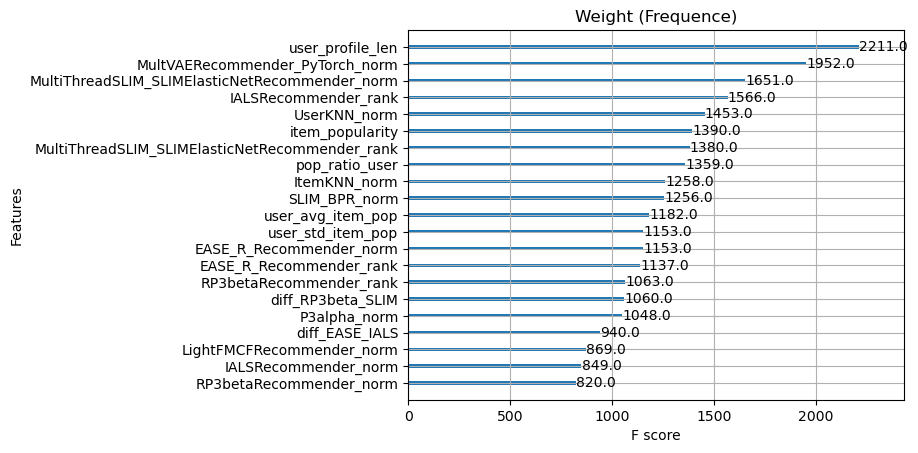

In [181]:
from xgboost import plot_importance
plot_importance(XGB_model, importance_type='weight', title='Weight (Frequence)')

<Axes: title={'center': 'Gain'}, xlabel='F score', ylabel='Features'>

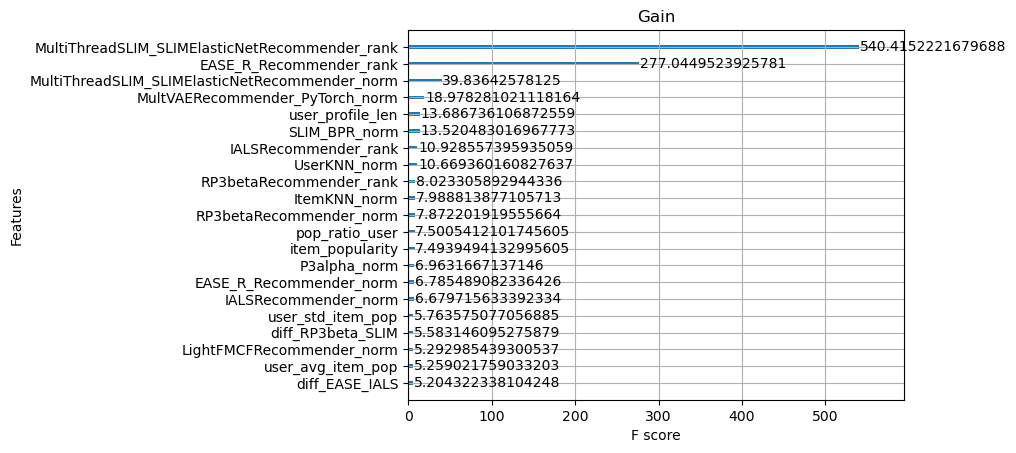

In [182]:
plot_importance(XGB_model, importance_type='gain', title='Gain')

<Axes: title={'center': 'Cover'}, xlabel='F score', ylabel='Features'>

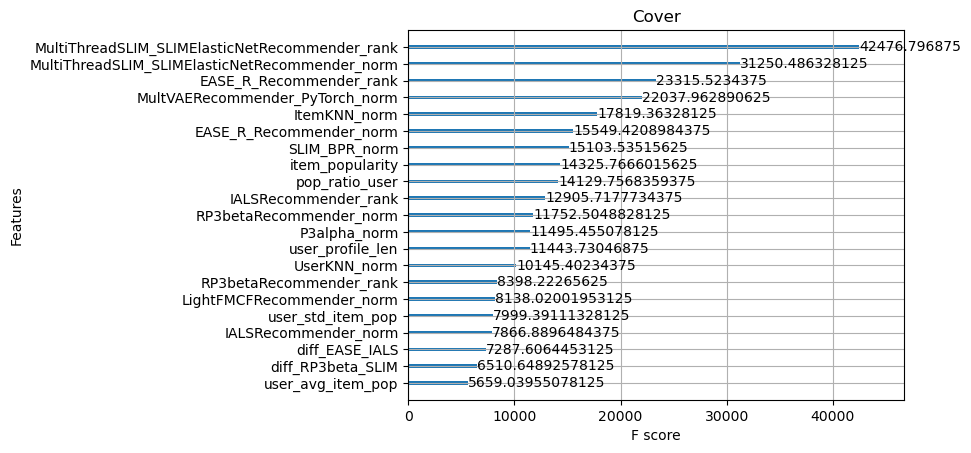

In [183]:
plot_importance(XGB_model, importance_type='cover', title='Cover')

# Retrain su tutto

In [184]:
other_algorithms_all = {}

import os

output_folder_path = "result_models_URM_ALL/"

# Se la cartella non esiste, creala
if not os.path.exists(output_folder_path):
    os.makedirs(output_folder_path)

for config in algorithm_configs:
    print("-------------------------------------------------")
    # Controllo se l'utente vuole usare questo algoritmo
    if config["use"]:
        recommender_instance = config["class"](URM_all)
        file_path = os.path.join(output_folder_path, config["label"] + ".zip")

        if config["load_model"] and os.path.exists(file_path):
            print(f"Loading model {config['label']}...")
            recommender_instance.load_model(folder_path=output_folder_path, file_name=config["label"])
            print(f"Modello {config['label']} caricato da '{file_path}'")

        else:
            # fitta
            print(f"Training {config['label']}...")
            recommender_instance.fit(**config["fit_params"])
            recommender_instance.save_model(folder_path=output_folder_path, file_name=config["label"])
            print(f"Modello {config['label']} salvato in '{output_folder_path}'")
        
        # Aggiungi al dizionario 
        other_algorithms_all[config["label"]] = recommender_instance

    else:
        print(f"Skipping {config['label']} (use=False)")

print(f"\nModelli pronti per XGBoost: {list(other_algorithms_all.keys())}")

-------------------------------------------------
Loading model UserKNN...
UserKNNCFRecommender: Loading model from file 'result_models_URM_ALL/UserKNN'
UserKNNCFRecommender: Loading complete
Modello UserKNN caricato da 'result_models_URM_ALL/UserKNN.zip'
-------------------------------------------------
Loading model ItemKNN...
ItemKNNCFRecommender: Loading model from file 'result_models_URM_ALL/ItemKNN'
ItemKNNCFRecommender: Loading complete
Modello ItemKNN caricato da 'result_models_URM_ALL/ItemKNN.zip'
-------------------------------------------------
Loading model RP3betaRecommender...
RP3betaRecommender: Loading model from file 'result_models_URM_ALL/RP3betaRecommender'
RP3betaRecommender: Loading complete
Modello RP3betaRecommender caricato da 'result_models_URM_ALL/RP3betaRecommender.zip'
-------------------------------------------------
Loading model P3alpha...
P3alphaRecommender: Loading model from file 'result_models_URM_ALL/P3alpha'
P3alphaRecommender: Loading complete
Mode

In [ ]:
import pandas as pd
import numpy as np
import gc

# -----------------------
# CONFIG
# -----------------------
import numpy as np
import scipy.sparse as sps

# Usa la matrice coerente con i modelli di inferenza:
URM_ref = URM_all  # oppure URM_train se vuoi coerenza col training (ma qui usi other_algorithms_all)

URM_ref_csr = URM_ref.tocsr()
URM_ref_csc = URM_ref.tocsc()

n_users, n_items = URM_ref_csr.shape

# 1) item_popularity: numero interazioni per item
item_pop_array = np.ediff1d(URM_ref_csc.indptr).astype(np.int32)

# 2) user_profile_len: numero interazioni per user
user_popularity = np.ediff1d(URM_ref_csr.indptr).astype(np.int32)

# 3) user_avg_item_pop e user_std_item_pop
user_avg_item_pop = np.zeros(n_users, dtype=np.float32)
user_std_item_pop = np.zeros(n_users, dtype=np.float32)



for u in range(n_users):
    start = URM_ref_csr.indptr[u]
    end   = URM_ref_csr.indptr[u+1]
    if end > start:
        items_u = URM_ref_csr.indices[start:end]
        pops = item_pop_array[items_u].astype(np.float32)
        user_avg_item_pop[u] = pops.mean()
        user_std_item_pop[u] = pops.std()
    else:
        user_avg_item_pop[u] = 0.0
        user_std_item_pop[u] = 0.0

print("Precompute ok:",
      "item_pop_array", item_pop_array.shape,
      "user_popularity", user_popularity.shape,
      "user_avg_item_pop", user_avg_item_pop.shape,
      "user_std_item_pop", user_std_item_pop.shape)



BATCH_SIZE = 1000
target_users = pd.read_csv("Data/data_target_users_test.csv")["user_id"].values
submission = []

# generatori candidati (puoi tenerli così)
candidate_models_for_test = [
    other_algorithms_all["RP3betaRecommender"],
    other_algorithms_all["IALSRecommender"],
    other_algorithms_all["UserKNN"],
    other_algorithms_all["ItemKNN"],
    other_algorithms_all["EASE_R_Recommender"],
    other_algorithms_all["MultiThreadSLIM_SLIMElasticNetRecommender"],
]
cutoff_candidates = 1000

# prefilter (3 forti) -> pesi
strong_models = [
    "MultiThreadSLIM_SLIMElasticNetRecommender",
    "EASE_R_Recommender",
    "RP3betaRecommender",
]
strong_weights = np.array([0.50, 0.35, 0.15], dtype=np.float32)
strong_weights = strong_weights / strong_weights.sum()

N_KEEP = 500  # uguale al tuo training prefilter

# -----------------------
# FEATURES FINALI
# -----------------------
features_to_use = [
    # --- NORM (sempre ON) ---
    'UserKNN_norm', 'ItemKNN_norm', 'RP3betaRecommender_norm', 'P3alpha_norm',
    'SLIM_BPR_norm', 'EASE_R_Recommender_norm',
    'MultiThreadSLIM_SLIMElasticNetRecommender_norm', 'IALSRecommender_norm',
    'LightFMCFRecommender_norm', 'MultVAERecommender_PyTorch_norm',

    # --- POP (use_pop=True) ---
    'item_popularity', 'user_profile_len', 'user_avg_item_pop', 'user_std_item_pop',
    'pop_ratio_user',

    # --- RANKS TOP (use_ranks_top=True) ---
    'RP3betaRecommender_rank',
    'EASE_R_Recommender_rank',
    'MultiThreadSLIM_SLIMElasticNetRecommender_rank',
    'IALSRecommender_rank',

    # --- DIFFS (use_diffs=True) ---
    'diff_RP3beta_SLIM',
    'diff_EASE_IALS',
]


# modelli necessari per creare le *_norm
models_needed = [
    "UserKNN",
    "ItemKNN",
    "RP3betaRecommender",
    "P3alpha",
    "SLIM_BPR",
    "EASE_R_Recommender",
    "MultiThreadSLIM_SLIMElasticNetRecommender",
    "IALSRecommender",
    "LightFMCFRecommender",
    "MultVAERecommender_PyTorch",
]

# sanity check
for m in models_needed:
    if m not in other_algorithms_all:
        raise ValueError(f"Missing model in other_algorithms_all: {m}")

print(f"Start prediction for {len(target_users)} users, batch={BATCH_SIZE}")

# -----------------------
# MAIN LOOP
# -----------------------
for start_idx in range(0, len(target_users), BATCH_SIZE):
    end_idx = min(start_idx + BATCH_SIZE, len(target_users))
    batch_users = target_users[start_idx:end_idx]

    # 1) union candidates
    users_list, items_list = [], []
    for u in batch_users:
        cand = set()
        for gen in candidate_models_for_test:
            cand.update(gen.recommend(u, cutoff=cutoff_candidates, remove_seen_flag=True))
        if len(cand) == 0:
            continue
        users_list.extend([u] * len(cand))
        items_list.extend(list(cand))

    if len(users_list) == 0:
        continue

    batch_df = pd.DataFrame({"UserID": users_list, "ItemID": items_list})

    # 2) prefilter: compute raw scores ONLY for strong models
    for name in strong_models:
        batch_df[name] = 0.0

    for u in batch_users:
        mask = (batch_df["UserID"] == u)
        user_items = batch_df.loc[mask, "ItemID"].values.astype(int)
        if len(user_items) == 0:
            continue

        for name in strong_models:
            model_obj = other_algorithms_all[name]
            s = model_obj._compute_item_score([u], items_to_compute=user_items)
            vals = s.flatten() if s.shape[1] == len(user_items) else s[0, user_items]
            batch_df.loc[mask, name] = vals

    # norm for strong + weighted score
    for name in strong_models:
        umax = batch_df.groupby("UserID")[name].transform("max")
        umin = batch_df.groupby("UserID")[name].transform("min")
        denom = (umax - umin).replace(0, 1)
        batch_df[f"{name}_norm"] = ((batch_df[name] - umin) / denom).fillna(0).astype(np.float32)

    strong_norm_cols = [f"{m}_norm" for m in strong_models]
    batch_df["prefilter_score"] = (batch_df[strong_norm_cols].values @ strong_weights).astype(np.float32)

    # keep top-N per user
    batch_df = (
        batch_df.sort_values(["UserID", "prefilter_score"], ascending=[True, False])
                .groupby("UserID", sort=False)
                .head(N_KEEP)
                .reset_index(drop=True)
    )

    # drop temporary prefilter columns
    drop_cols = ["prefilter_score"] + strong_models + strong_norm_cols
    drop_cols = [c for c in drop_cols if c in batch_df.columns]
    batch_df.drop(columns=drop_cols, inplace=True)

    # 3) compute raw scores for all models_needed (now on filtered candidates)
    for m in models_needed:
        batch_df[m] = 0.0

    for u in batch_users:
        mask = (batch_df["UserID"] == u)
        user_items = batch_df.loc[mask, "ItemID"].values.astype(int)
        if len(user_items) == 0:
            continue

        for m in models_needed:
            model_obj = other_algorithms_all[m]
            s = model_obj._compute_item_score([u], items_to_compute=user_items)
            vals = s.flatten() if s.shape[1] == len(user_items) else s[0, user_items]
            batch_df.loc[mask, m] = vals

    # 4) build *_norm features required
    for m in models_needed:
        umax = batch_df.groupby("UserID")[m].transform("max")
        umin = batch_df.groupby("UserID")[m].transform("min")
        denom = (umax - umin).replace(0, 1)
        batch_df[f"{m}_norm"] = ((batch_df[m] - umin) / denom).fillna(0).astype(np.float32)
        
    rank_models = [
        "RP3betaRecommender",
        "EASE_R_Recommender",
        "MultiThreadSLIM_SLIMElasticNetRecommender",
        "IALSRecommender"
    ]

    for m in rank_models:
        norm_col = f"{m}_norm"
        rank_col = f"{m}_rank"
        if norm_col in batch_df.columns and rank_col not in batch_df.columns:
            batch_df[rank_col] = (
                batch_df.groupby("UserID")[norm_col]
                        .rank(ascending=False, method="min")
                        .astype("int32")
            )

    # --- diffs ---
    if "RP3betaRecommender_norm" in batch_df.columns and "SLIM_BPR_norm" in batch_df.columns:
        batch_df["diff_RP3beta_SLIM"] = (
            batch_df["RP3betaRecommender_norm"] - batch_df["SLIM_BPR_norm"]
        ).astype("float32")
    else:
        batch_df["diff_RP3beta_SLIM"] = 0.0

    if "EASE_R_Recommender_norm" in batch_df.columns and "IALSRecommender_norm" in batch_df.columns:
        batch_df["diff_EASE_IALS"] = (
            batch_df["EASE_R_Recommender_norm"] - batch_df["IALSRecommender_norm"]
        ).astype("float32")
    else:
        batch_df["diff_EASE_IALS"] = 0.0 

    # drop raw score cols (optional)
    batch_df.drop(columns=models_needed, inplace=True)

    # 5) add pop/profile features
    batch_df["item_popularity"] = item_pop_array[batch_df["ItemID"].values.astype(int)]
    batch_df["user_profile_len"] = user_popularity[batch_df["UserID"].values.astype(int)]

    batch_df["user_avg_item_pop"] = batch_df["UserID"].map(lambda x: user_avg_item_pop[x]).astype(np.float32)
    batch_df["user_std_item_pop"] = batch_df["UserID"].map(lambda x: user_std_item_pop[x]).astype(np.float32)

    batch_df["pop_ratio_user"] = (batch_df["item_popularity"] / (batch_df["user_avg_item_pop"] + 1)).astype(np.float32)

    # 6) add cluster distance features dist_cluster_0..9
    u_ids = batch_df["UserID"].values.astype(int)
    dists = user_distances[u_ids]  # shape (rows, 10)
    for i in range(10):
        batch_df[f"dist_cluster_{i}"] = dists[:, i].astype(np.float32)

    # 7) predict XGB
    X_batch = batch_df[features_to_use]
    batch_df["xgb_score"] = XGB_model.predict(X_batch)

    # 8) build top20
    for u in batch_users:
        user_recs = batch_df[batch_df["UserID"] == u].sort_values("xgb_score", ascending=False)
        top20 = user_recs["ItemID"].head(20).values
        submission.append((u, " ".join(map(str, top20))))

    del batch_df, X_batch
    gc.collect()
    print(f"Batch completed: {end_idx}/{len(target_users)}", end="\r")

submission_df = pd.DataFrame(submission, columns=["user_id", "item_list"])
submission_df.to_csv("submission_xgboost_batched.csv", index=False)
print("\nDone! Saved: submission_xgboost_batched.csv")


Precompute ok: item_pop_array (6969,) user_popularity (27095,) user_avg_item_pop (27095,) user_std_item_pop (27095,)
Start prediction for 27095 users, batch=1000
Batch completed: 27095/27095
Done! Saved: submission_xgboost_batched.csv
